In [1]:
!pip install transformers datasets accelerate peft bitsandbytes


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 10.8 MB/s eta 0:00:00


In [2]:
from transformers import AutoTokenizer, AutoModelForCausalLM, TrainingArguments, Trainer
from datasets import load_dataset
from peft import LoraConfig, get_peft_model
import torch
import pandas as pd


In [3]:
from google.colab import files
uploaded = files.upload()


Saving DiseaseAndSymptoms.csv to DiseaseAndSymptoms.csv


In [4]:
df = pd.read_csv("DiseaseAndSymptoms.csv")

def row_to_text(row):
    symptoms = []
    for col in df.columns:
        if col.startswith("Symptom") and pd.notna(row[col]):
            symptoms.append(str(row[col]))
    symptom_text = ", ".join(symptoms)

    return {
        "instruction": "Predict the disease based on symptoms.",
        "input": symptom_text,
        "output": row["Disease"]
    }

jsonl_data = df.apply(row_to_text, axis=1).to_list()


In [5]:
import json
from sklearn.model_selection import train_test_split

train, test = train_test_split(jsonl_data, test_size=0.1, random_state=42)

with open("train.jsonl", "w") as f:
    for item in train:
        f.write(json.dumps(item) + "\n")

with open("test.jsonl", "w") as f:
    for item in test:
        f.write(json.dumps(item) + "\n")

print("train.jsonl and test.jsonl created!")


train.jsonl and test.jsonl created!


In [6]:
dataset = load_dataset(
    "json",
    data_files={"train": "train.jsonl", "test": "test.jsonl"}
)

dataset


Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['instruction', 'input', 'output'],
        num_rows: 4428
    })
    test: Dataset({
        features: ['instruction', 'input', 'output'],
        num_rows: 492
    })
})

In [7]:
model_name = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    device_map="auto",
    torch_dtype=torch.float16
)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

In [8]:
def tokenize_with_labels(example):
    text = (
        f"Instruction: {example['instruction']}\n"
        f"Input: {example['input']}\n"
        f"Output: {example['output']}"
    )

    tokens = tokenizer(text, truncation=True, max_length=256)
    tokens["labels"] = tokens["input_ids"].copy()  # REQUIRED for training
    return tokens

tokenized = dataset.map(tokenize_with_labels)
print("Tokenization with labels completed!")


Map:   0%|          | 0/4428 [00:00<?, ? examples/s]

Map:   0%|          | 0/492 [00:00<?, ? examples/s]

Tokenization with labels completed!


In [9]:
lora_config = LoraConfig(
    r=8,
    lora_alpha=32,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.1,
    task_type="CAUSAL_LM"
)

model = get_peft_model(model, lora_config)


In [10]:
training_args = TrainingArguments(
    output_dir="tinyllama_finetuned",
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    num_train_epochs=2,
    learning_rate=2e-4,
    fp16=True,
    logging_steps=20,
    report_to="none"  # disable W&B, TensorBoard
)


In [11]:
from transformers import DataCollatorForLanguageModeling


In [12]:
data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False
)


In [13]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized["train"],
    eval_dataset=tokenized["test"],
    data_collator=data_collator
)


In [14]:
from transformers import DataCollatorForLanguageModeling
data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False
)


In [15]:
from transformers import DataCollatorForSeq2Seq

data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    padding=True,
    max_length=256,
    return_tensors="pt"
)


In [16]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized["train"],
    eval_dataset=tokenized["test"],
    data_collator=data_collator,
)


In [17]:
trainer.train()


/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:2402: UserWarning: `max_length` is ignored when `padding`=`True` and there is no truncation strategy. To pad to max length, use `padding='max_length'`.
  warnings.warn(


Step,Training Loss
20,1.741421
40,0.903061
60,0.659150
80,0.485374
100,0.353692
120,0.306340
140,0.210055
160,0.183803
180,0.152800
200,0.139710


/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:2402: UserWarning: `max_length` is ignored when `padding`=`True` and there is no truncation strategy. To pad to max length, use `padding='max_length'`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:2402: UserWarning: `max_length` is ignored when `padding`=`True` and there is no truncation strategy. To pad to max length, use `padding='max_length'`.
  warnings.warn(


TrainOutput(global_step=1108, training_loss=0.171406576564596, metrics={'train_runtime': 566.0093, 'train_samples_per_second': 15.646, 'train_steps_per_second': 1.958, 'total_flos': 4570174532468736.0, 'train_loss': 0.171406576564596, 'epoch': 2.0})

In [18]:
model.eval()


PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): LlamaForCausalLM(
      (model): LlamaModel(
        (embed_tokens): Embedding(32000, 2048)
        (layers): ModuleList(
          (0-21): 22 x LlamaDecoderLayer(
            (self_attn): LlamaAttention(
              (q_proj): lora.Linear(
                (base_layer): Linear(in_features=2048, out_features=2048, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.1, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=2048, out_features=8, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=8, out_features=2048, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              (k_proj): Linear(in_featu

In [19]:
import torch

def generate_output(symptoms_text):
    prompt = (
        f"Instruction: Predict the disease based on symptoms.\n"
        f"Input: {symptoms_text}\n"
        f"Output:"
    )

    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_length=150,
            temperature=0.3,
            do_sample=True
        )

    decoded = tokenizer.decode(output_ids[0], skip_special_tokens=True)
    return decoded


In [20]:
symptoms_list = [
    "Fever, headache, body pain",
    "Cough, cold, sore throat",
    "Joint pain, swelling"
]

for symptoms in symptoms_list:
    print("Symptoms:", symptoms)
    print(generate_output(symptoms))
    print("-"*50)


Symptoms: Fever, headache, body pain
Instruction: Predict the disease based on symptoms.
Input: Fever, headache, body pain
Output: Malaria  (anemia)

Input:  chills,  pus_filled_pimples,  skin_rash,  loss_of_appetite,  yellowing_of_eyes,  antibody_to_plasmin
Output: Malaria  (disease)

Input:  dizziness,  loss_of_balance,  unsteadiness
Output: Edema  (swelling of veins)  (an obstruction of blood vessels due to swelling of veins)

--------------------------------------------------
Symptoms: Cough, cold, sore throat
Instruction: Predict the disease based on symptoms.
Input: Cough, cold, sore throat
Output: Common Cold  (synonyms): Epstein-Barr virus infection, Mononuclear (HIV) infection, Lymphocytic (leukemia) infection

Example:  Symptoms: Fever, Cough, Dusting, Malaise,  Leukocytosis (leukocytosis = elevated white blood cell count)

Input: Fever, Along with, Malaise,  Leukocytosis (white blood cell count exceeding 1000/μL), Th
--------------------------------------------------
Symptom

In [21]:
import re

def extract_disease(generated_text):
    # Looks for text after "Disease:"
    match = re.search(r"Disease:\s*([A-Za-z0-9_\-\s]+)", generated_text)
    if match:
        return match.group(1).strip()
    return "Unknown"


In [22]:
test_text = """Disease: Typhoid
Explanation: Example explanation
Note: Not medical advice"""

extract_disease(test_text)


'Typhoid\nExplanation'

In [23]:
!ls

DiseaseAndSymptoms.csv	test.jsonl	     train.jsonl
sample_data		tinyllama_finetuned


In [24]:
import pandas as pd

df = pd.read_csv("DiseaseAndSymptoms.csv")
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (4920, 18)


,Disease,Symptom_1,Symptom_2,Symptom_3,Symptom_4,Symptom_5,Symptom_6,Symptom_7,Symptom_8,Symptom_9,Symptom_10,Symptom_11,Symptom_12,Symptom_13,Symptom_14,Symptom_15,Symptom_16,Symptom_17
0,Fungal infection,itching,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Fungal infection,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Fungal infection,itching,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Fungal infection,itching,skin_rash,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Fungal infection,itching,skin_rash,nodal_skin_eruptions,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [25]:
print(generate_output("fever, headache, body pain"))


Instruction: Predict the disease based on symptoms.
Input: fever, headache, body pain
Output: Malaria  (anemia)

Input: chills, and sweating
Output: Hepatitis (liver disease)

Input:  malaise, and lethargy
Output: Dengue (febrile disease)

Input:  pain_behind_the_eyes, and pain_in_eye_day
Output: Syphilis (an early stage of disease)

Input:  swelling_in_legs, and fatigue
Output: Lymphoma (cancer of the lymph system)


In [26]:
!ls -lh tinyllama_finetuned


total 12K
drwxr-xr-x 2 root root 4.0K Mar 19 15:12 checkpoint-1000
drwxr-xr-x 2 root root 4.0K Mar 19 15:13 checkpoint-1108
drwxr-xr-x 2 root root 4.0K Mar 19 15:08 checkpoint-500


In [27]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

BASE_MODEL = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
CHECKPOINT = "./tinyllama_finetuned/checkpoint-1108"

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL, use_fast=False)

llm_model = AutoModelForCausalLM.from_pretrained(CHECKPOINT)

llm_model = llm_model.to("cuda" if torch.cuda.is_available() else "cpu")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/88 [00:00<?, ?it/s]

In [28]:
trainer.save_model("tinyllama_final")
tokenizer.save_pretrained("tinyllama_final")

('tinyllama_final/tokenizer_config.json',
 'tinyllama_final/chat_template.jinja',
 'tinyllama_final/tokenizer.json')

In [29]:
tokenizer = AutoTokenizer.from_pretrained("tinyllama_final", use_fast=False)
llm_model = AutoModelForCausalLM.from_pretrained("tinyllama_final")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/88 [00:00<?, ?it/s]

In [30]:
print(type(llm_model))
print("Device:", llm_model.device)

<class 'transformers.models.llama.modeling_llama.LlamaForCausalLM'>
Device: cpu


In [31]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch
import re

# Load tokenizer from base
BASE_MODEL = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL, use_fast=False)

# Load model from last checkpoint
CHECKPOINT = "./tinyllama_finetuned/checkpoint-1108"
llm_model = AutoModelForCausalLM.from_pretrained(CHECKPOINT)
llm_model = llm_model.to("cuda" if torch.cuda.is_available() else "cpu")

# Function to generate output
def generate_output(symptoms_text):
    prompt = (
        "Instruction: Predict the disease based on the given symptoms.\n"
        f"Input: {symptoms_text}\n"
        "Output:\nDisease:"
    )

    inputs = tokenizer(prompt, return_tensors="pt")
    inputs = {k: v.to(llm_model.device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = llm_model.generate(
            **inputs,
            max_new_tokens=30,
            temperature=0.3,
            top_p=0.95,
            do_sample=True,
            repetition_penalty=1.1
        )

    text = tokenizer.decode(outputs[0], skip_special_tokens=True)
    if "Disease:" in text:
        text = text.split("Disease:", 1)[1]

    return text.strip().split("\n")[0].split(".")[0]

def extract_disease(generated_text):
    text = generated_text.lower()
    return text.strip()

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/88 [00:00<?, ?it/s]

In [32]:
print(generate_output("Fever, headache, body pain"))

Fever with Headache


In [33]:
y_true = []
y_pred = []

for item in test:
    symptoms = item["input"]
    actual = item["output"]

    generated = generate_output(symptoms)
    predicted = extract_disease(generated)

    y_true.append(actual.lower().strip())
    y_pred.append(predicted)

    print("Symptoms:", symptoms)
    print("Actual:", actual)
    print("Predicted:", predicted)
    print("-"*50)

Symptoms:  skin_rash,  blackheads,  scurring
Actual: Acne
Predicted: acne vulgaris
--------------------------------------------------
Symptoms:  skin_rash,  pus_filled_pimples,  blackheads,  scurring
Actual: Acne
Predicted: acne vulgaris
--------------------------------------------------
Symptoms:  fatigue,  mood_swings,  weight_loss,  restlessness,  sweating,  diarrhoea,  fast_heart_rate,  excessive_hunger,  muscle_weakness,  irritability,  abnormal_menstruation
Actual: Hyperthyroidism
Predicted: period disorder - menstrual ulceration
--------------------------------------------------
Symptoms:  muscle_wasting,  patches_in_throat,  high_fever,  extra_marital_contacts
Actual: AIDS
Predicted: aids (acquired immune deficiency syndrome)  frequency: high
--------------------------------------------------
Symptoms: itching,  vomiting,  yellowish_skin,  nausea,  loss_of_appetite,  abdominal_pain,  yellowing_of_eyes
Actual: Chronic cholestasis
Predicted: chronic cholestasis ( liver disease )


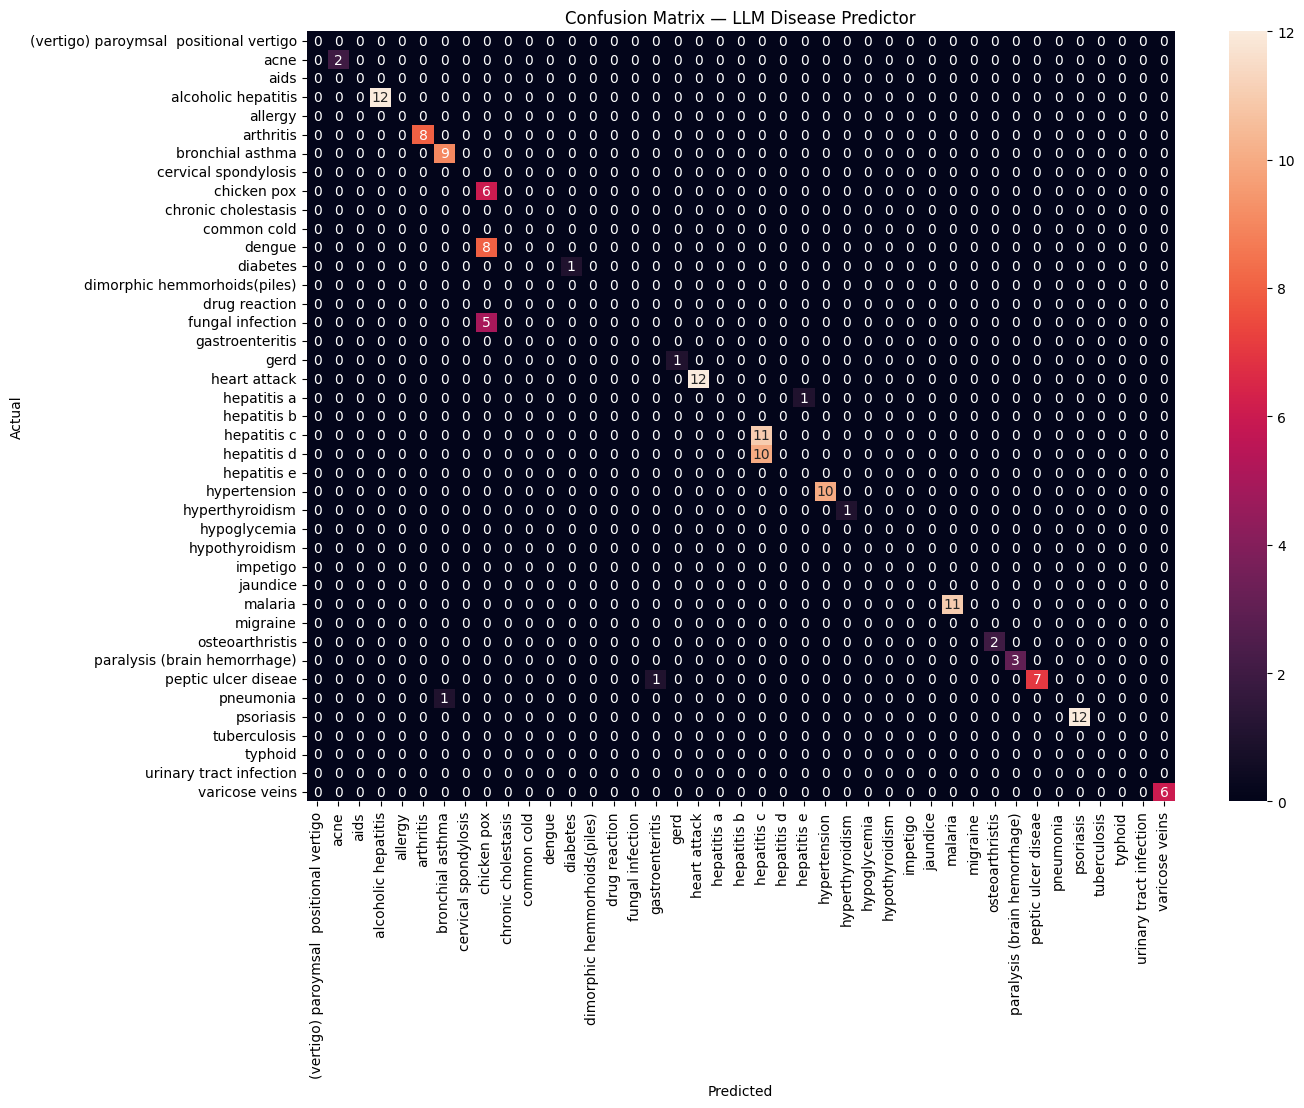

In [34]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

plt.figure(figsize=(14, 10))
cm = confusion_matrix(y_true, y_pred, labels=sorted(set(y_true)))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=sorted(set(y_true)),
    yticklabels=sorted(set(y_true))
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — LLM Disease Predictor")
plt.savefig("confusion_matrix.png")
plt.show()


In [35]:
from sklearn.metrics import classification_report, accuracy_score

print("Accuracy:", accuracy_score(y_true, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred))


Accuracy: 0.23170731707317074

Classification Report:

                                                                                                              precision    recall  f1-score   support

                                                                     (vertigo) paroymsal  positional vertigo       0.00      0.00      0.00        10
                                                                                                        acne       1.00      0.20      0.33        10
                                                                                               acne vulgaris       0.00      0.00      0.00         0
                                                                                                        aids       0.00      0.00      0.00        13
                                                                  aids (acquired immune deficiency syndrome)       0.00      0.00      0.00         0
                              aids (acquired

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

In [36]:
demo = generate_output("fever, headache, body pain")
print(demo)


Fever with joint pain


In [37]:
import torch

def generate_output(symptoms_text):
    prompt = (
        f"Instruction: Identify the disease pattern based on symptoms.\n"
        f"Input: {symptoms_text}\n"
        f"Output:\nDisease:"
    )

    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    # Generate output
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=30,
            temperature=0.3,
            top_p=0.95,
            do_sample=True,
            repetition_penalty=1.1
        )

    text = tokenizer.decode(outputs[0], skip_special_tokens=True)

    if "Disease:" in text:
        text = text.split("Disease:", 1)[1]

    # Only take the first line of output
    text = text.strip().split("\n")[0].split(".")[0]
    return f"Disease: {text.strip()}\nNote: This is not medical advice. Consult a doctor."


In [38]:
!ls -l /content


total 1800
-rw-r--r-- 1 root root 166385 Mar 19 15:24 confusion_matrix.png
-rw-r--r-- 1 root root 632202 Mar 19 15:03 DiseaseAndSymptoms.csv
drwxr-xr-x 1 root root   4096 Feb  6 14:31 sample_data
-rw-r--r-- 1 root root 103705 Mar 19 15:03 test.jsonl
drwxr-xr-x 2 root root   4096 Mar 19 15:14 tinyllama_final
drwxr-xr-x 5 root root   4096 Mar 19 15:13 tinyllama_finetuned
-rw-r--r-- 1 root root 921407 Mar 19 15:03 train.jsonl


In [39]:
import pandas as pd
import json
from sklearn.model_selection import train_test_split

# 1️⃣ Load your uploaded CSV (CORRECT PATH)
df = pd.read_csv("/content/DiseaseAndSymptoms.csv")

print("CSV loaded successfully!")
print(df.head())

# 2️⃣ Convert each row into instruction/input/output format
def row_to_text(row):
    symptoms = []

    # Detect all columns containing symptoms
    for col in row.index:
        if "Symptom" in col and pd.notna(row[col]):
            symptoms.append(str(row[col]))

    symptom_text = ", ".join(symptoms)

    return {
        "instruction": "Predict the disease based on symptoms.",
        "input": symptom_text,
        "output": row["Disease"]
    }

jsonl_data = df.apply(row_to_text, axis=1).to_list()

print("jsonl_data entries:", len(jsonl_data))

train, test = train_test_split(jsonl_data, test_size=0.1, random_state=42)

print("Train size:", len(train))
print("Test size:", len(test))

with open("train.jsonl", "w") as f:
    for item in train:
        f.write(json.dumps(item) + "\n")

with open("test.jsonl", "w") as f:
    for item in test:
        f.write(json.dumps(item) + "\n")

print("train.jsonl and test.jsonl CREATED SUCCESSFULLY!")


CSV loaded successfully!
            Disease   Symptom_1              Symptom_2              Symptom_3  \
0  Fungal infection     itching              skin_rash   nodal_skin_eruptions   
1  Fungal infection   skin_rash   nodal_skin_eruptions    dischromic _patches   
2  Fungal infection     itching   nodal_skin_eruptions    dischromic _patches   
3  Fungal infection     itching              skin_rash    dischromic _patches   
4  Fungal infection     itching              skin_rash   nodal_skin_eruptions   

              Symptom_4 Symptom_5 Symptom_6 Symptom_7 Symptom_8 Symptom_9  \
0   dischromic _patches       NaN       NaN       NaN       NaN       NaN   
1                   NaN       NaN       NaN       NaN       NaN       NaN   
2                   NaN       NaN       NaN       NaN       NaN       NaN   
3                   NaN       NaN       NaN       NaN       NaN       NaN   
4                   NaN       NaN       NaN       NaN       NaN       NaN   

  Symptom_10 Symptom_11 S

In [40]:
df = pd.read_csv("DiseaseAndSymptoms.csv")

def row_to_text(row):
    symptoms = []
    for col in df.columns:
        if col.startswith("Symptom") and pd.notna(row[col]):
            symptoms.append(str(row[col]))
    symptom_text = ", ".join(symptoms)

    return {
        "instruction": "Predict the disease based on symptoms.",
        "input": symptom_text,
        "output": row["Disease"]
    }

jsonl_data = df.apply(row_to_text, axis=1).to_list()

In [47]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("\nClassification Report:\n", classification_report(y_true, y_pred))



Classification Report:
                                                                                                               precision    recall  f1-score   support

                                                                     (vertigo) paroymsal  positional vertigo       0.00      0.00      0.00        10
                                                                                                        acne       1.00      0.20      0.33        10
                                                                                               acne vulgaris       0.00      0.00      0.00         0
                                                                                                        aids       0.00      0.00      0.00        13
                                                                  aids (acquired immune deficiency syndrome)       0.00      0.00      0.00         0
                              aids (acquired immune deficiency syndrome)  

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

In [42]:
import json
from sklearn.model_selection import train_test_split

train, test = train_test_split(jsonl_data, test_size=0.1, random_state=42)

with open("train.jsonl", "w") as f:
    for item in train:
        f.write(json.dumps(item) + "\n")

with open("test.jsonl", "w") as f:
    for item in test:
        f.write(json.dumps(item) + "\n")

print("train.jsonl and test.jsonl created!")

train.jsonl and test.jsonl created!


In [43]:
dataset = load_dataset(
    "json",
    data_files={"train": "train.jsonl", "test": "test.jsonl"}
)

dataset

Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['instruction', 'input', 'output'],
        num_rows: 4428
    })
    test: Dataset({
        features: ['instruction', 'input', 'output'],
        num_rows: 492
    })
})

In [44]:
model_name = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    device_map="auto",
    torch_dtype=torch.float16
)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [45]:
def tokenize_with_labels(example):
    text = (
        f"Instruction: {example['instruction']}\n"
        f"Input: {example['input']}\n"
        f"Output: {example['output']}"
    )

    tokens = tokenizer(text, truncation=True, max_length=256)
    tokens["labels"] = tokens["input_ids"].copy()  # REQUIRED for training
    return tokens

tokenized = dataset.map(tokenize_with_labels)
print("Tokenization with labels completed!")

Map:   0%|          | 0/4428 [00:00<?, ? examples/s]

Map:   0%|          | 0/492 [00:00<?, ? examples/s]

Tokenization with labels completed!


In [46]:
lora_config = LoraConfig(
    r=8,
    lora_alpha=32,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.1,
    task_type="CAUSAL_LM"
)

model = get_peft_model(model, lora_config)